In [2]:
!pip install pulp


Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/16.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/16.4 MB ? eta -:--:--
   --- ------------------------------------ 1.3/16.4 MB 13.4 MB/s eta 0:00:02
   ------------ --------------------------- 5.0/16.4 MB 15.9 MB/s eta 0:00:01
   --------------------- ------------------ 8.7/16.4 MB 16.3 MB/s eta 0:00:01
   --------------------------- ------------ 11.3/16.4 MB 15.7 MB/s eta 0:00:01
   ------------------------------ --------- 12.6/16.4 MB 13.1 MB/s eta 0:00:01
   --------------------------------- ------ 13.9/16.4 MB 11.9 MB/s eta 0:00:01
   -------------------------------------- - 15.7/16.4 MB 11.4 MB/s eta 0:00:01
   ---------------------------------------- 16.4/16.4 MB 10.8 MB/s  0:00:01



[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from pulp import *

In [8]:
data = {
    "Product": ["Laptop","Phone","Tablet","Watch"],
    "Profit_per_unit": [120,80,100,50],
    "Material_required": [5,3,4,2],
    "Labor_hours": [3,2,3,1],
    "Machine_hours": [4,2,3,1],
    "Demand": [100,200,150,300]
}

df = pd.DataFrame(data)

df

,Product,Profit_per_unit,Material_required,Labor_hours,Machine_hours,Demand
0,Laptop,120,5,3,4,100
1,Phone,80,3,2,2,200
2,Tablet,100,4,3,3,150
3,Watch,50,2,1,1,300


In [9]:
df.to_csv("products.csv", index=False)

In [10]:
df

,Product,Profit_per_unit,Material_required,Labor_hours,Machine_hours,Demand
0,Laptop,120,5,3,4,100
1,Phone,80,3,2,2,200
2,Tablet,100,4,3,3,150
3,Watch,50,2,1,1,300


In [11]:
#Business Constraints
total_material = 1000

total_labor = 500

total_machine = 600

In [12]:
#optimization model
model = LpProblem(
    "Supply_Chain_Optimization",
    LpMaximize
)

In [13]:
#decision variables
products = df["Product"]


x = LpVariable.dicts(
    "Production",
    products,
    lowBound=0,
    cat="Integer"
)

In [14]:
#Objective function
model += lpSum(
    x[i] * df.loc[df["Product"]==i,"Profit_per_unit"].values[0]
    for i in products
)


In [15]:
#materials contsraints
model += lpSum(
    x[i] * df.loc[df["Product"]==i,"Material_required"].values[0]
    for i in products
) <= total_material

In [16]:
#Labor constraints
model += lpSum(
    x[i] * df.loc[df["Product"]==i,"Labor_hours"].values[0]
    for i in products
) <= total_labor

In [17]:
#Machine Constraints
model += lpSum(
    x[i] * df.loc[df["Product"]==i,"Machine_hours"].values[0]
    for i in products
) <= total_machine

In [18]:
#demand constraints
for i in products:

    demand = df.loc[
        df["Product"]==i,
        "Demand"
    ].values[0]


    model += x[i] <= demand

In [19]:
model.solve()

1

In [20]:
print(
    LpStatus[model.status]
)

Optimal


In [21]:
results=[]


for i in products:

    results.append(
        {
        "Product":i,
        "Production":x[i].value()
        }
    )


result_df=pd.DataFrame(results)

result_df

,Product,Production
0,Laptop,0.0
1,Phone,100.0
2,Tablet,0.0
3,Watch,300.0


In [22]:
print(
"Maximum Profit:",
value(model.objective)
)

Maximum Profit: 23000.0


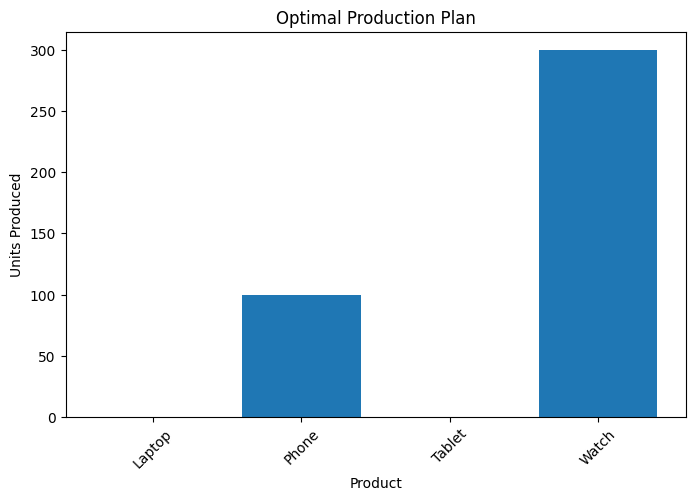

In [23]:
plt.figure(figsize=(8,5))


plt.bar(
    result_df["Product"],
    result_df["Production"]
)


plt.xlabel("Product")

plt.ylabel("Units Produced")

plt.title(
"Optimal Production Plan"
)


plt.xticks(rotation=45)

plt.show()

### Insights
1.The optimization model suggests producing 100 units of Phone and 300 units of Smart Watch to achieve the best production strategy under the given resource constraints.

2.The model did not allocate production to Laptop and Tablet because the available resources are better utilized by producing products that provide higher returns under the current constraints.

3.Smart Watch received the highest production quantity (300 units) because it requires fewer resources (material, labor, and machine hours) while still contributing to overall profit.

4.The optimization approach helps the company avoid unnecessary production and focuses resources on the most beneficial products.

5.The result demonstrates that Linear Programming can support business decision-making by finding an optimal balance between:
-profit maximization
-resource availability
-production limits

6.The company can use this model to improve production planning and increase operational efficiency.